In [1]:
import torch
import torch.fft
import numpy as np
import matplotlib.pyplot as plt
import helper_functions as hlp
np.random.seed(42)


In [2]:
import numpy as np

# Loading the file
data = np.load('simulation_results.npz')

# Access to the saved parameters
t = data['time']
s_nulled = data['s_nulled']
Fs = data['Fs']
freqs = data['freqs']
S_orig_norm = data['S_orig_norm']
T = data['T']
s_lin = data['s_lin']

print(f"Loaded phasor with shape: {t.shape}")

B = 2e6


Loaded phasor with shape: (600,)


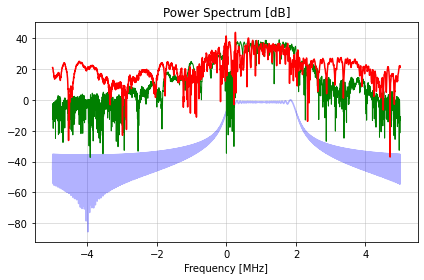

In [3]:
# Checking that the signals are really the signals.
# We will observe the non-normalized signals for better comparison.
freqs_nulled, S_nulled = hlp.spectrum(s_nulled, Fs, 2**14)
S_nulled_db = 20*np.log10(np.abs(S_nulled) + 1e-80)

freqs, S_lin = hlp.spectrum(s_lin, Fs, 2**14)
S_linear_db = 20*np.log10(np.abs(S_lin)+1e-80)


plt.figure()

plt.plot(freqs/1e6, S_orig_norm, label='Original LFM', color='blue', alpha=0.3) # original signal
plt.plot(freqs/1e6, S_nulled_db, label='Optimized Signal', color='green', linewidth=1) # optimized signal
plt.plot(freqs/1e6, S_linear_db, label='Linearized Solution', color='red')

plt.title("Power Spectrum [dB]")
plt.xlabel("Frequency [MHz]")

#plt.legend(loc='upper right')
plt.grid(True, alpha=0.5)
#plt.xlim(-0.5, 0.5)
#plt.ylim(-78, 5)
plt.tight_layout()
plt.show()

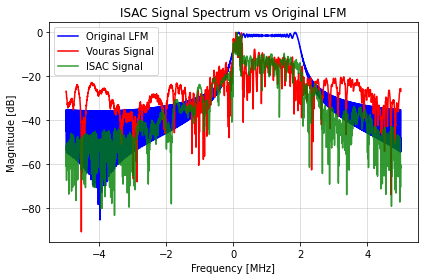

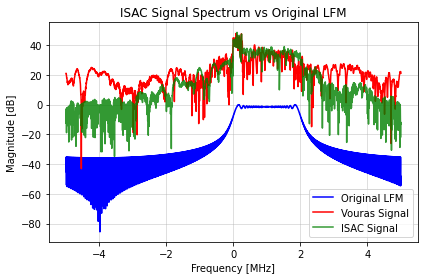

In [4]:
# OFDM signal generation
from OFDM_2 import OFDM, OFDM_demodulate, QPSK_modulation
import OFDM_2

num_subcarriers = 16

bits = np.random.randint(0, 2, num_subcarriers*2)
QPSK_data = QPSK_modulation(bits)

OFDM_signal = OFDM(QPSK_data, t=t, num = num_subcarriers, normalize=True)

#ISAC
isac_signal = s_nulled + OFDM_signal # same scale (order of Mag)
vouras_signal = s_lin + OFDM_signal

OFDM_freqs, OFDM_SIG = hlp.spectrum(OFDM_signal, Fs, 2**14)

ISAC_freqs, ISAC_SIGNAL = hlp.spectrum(isac_signal, Fs, 2**14)
VOURAS_freqs, VOURAS_SIGNAL = hlp.spectrum(vouras_signal, Fs, 2**14)

I2 = S_nulled + OFDM_SIG
V2 = S_lin + OFDM_SIG

I2_db = 20*np.log10(np.abs(I2) + 1e-40)
V2_db = 20*np.log10(np.abs(V2) + 1e-40)

S_isac_db = 20*np.log10(np.abs(ISAC_SIGNAL) + 1e-40)
S_isac_norm = 20*np.log10(np.abs(ISAC_SIGNAL)/np.max(np.abs(ISAC_SIGNAL))+1e-40)

S_vouras_db = 20*np.log10(np.abs(VOURAS_SIGNAL) + 1e-40)
S_vouras_norm = 20*np.log10(np.abs(VOURAS_SIGNAL)/np.max(np.abs(VOURAS_SIGNAL))+1e-40)

# plotting results in the frequency domain
plt.figure()
plt.plot(freqs/1e6, S_orig_norm, label='Original LFM', color='blue')
plt.plot(VOURAS_freqs/1e6, S_vouras_norm, label='Vouras Signal', color='red')
plt.plot(ISAC_freqs/1e6, S_isac_norm, label='ISAC Signal', color='green', alpha=0.8)
# plt.plot(freqs/1e6, S_final_norm, label='Final Signal', color='red')
plt.title("ISAC Signal Spectrum vs Original LFM")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(freqs/1e6, S_orig_norm, label='Original LFM', color='blue')
plt.plot(VOURAS_freqs/1e6, V2_db, label='Vouras Signal', color='red')
plt.plot(ISAC_freqs/1e6, I2_db, label='ISAC Signal', color='green', alpha=0.8)
# plt.plot(freqs/1e6, S_final_norm, label='Final Signal', color='red')
plt.title("ISAC Signal Spectrum vs Original LFM")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
# Matching Receiver Designation
"""
For now, we assume a non-observable environment.
The Sensing part of the signal will only be checked by the PSLR-ISLR metrics.
"""


def isac_receiver(isac_signal):
    
    return OFDM_2.OFDM_demodulate(isac_signal, num_subcarriers)

plt.figure(figsize=(6, 6))

def data_generate (length=num_subcarriers, seed=42):
    np.random.seed(seed)
    bits = np.random.randint(0, 2, length*2)
    QPSK_symbols = QPSK_modulation(bits)

def isac_transimtter (nulled_chirp=s_nulled, QPSK_symbols=QPSK_data, t=t, num=num_subcarriers):
    OFDM_signal = OFDM(QPSK_symbols, t=t, num=num, normalize=True)
    isac_signal = nulled_chirp + OFDM_signal
    return isac_signal



# AWGN Channel
def channel (isac_signal=isac_signal, ofdm_signal=OFDM_signal, SNR_val=0, num=num_subcarriers, alpha=1/2):
    #np.random.seed(seed)
    #signal_energy = (1/T) * np.abs(np.trapezoid(ofdm_signal*np.conj(ofdm_signal), x=t)) # energy for signal (num symbols)
    #Es = signal_energy

    Es = (1-alpha)/num_subcarriers 
    
    #Es = np.mean(np.abs(OFDM_signal)**2)
    
    SNR_linear = 10**(SNR_val / 10)
    N0 = Es / SNR_linear
    sigma = np.sqrt(N0*600/2)
    noise = np.random.normal(0, sigma, size=len(isac_signal)) + 1j*np.random.normal(0, sigma, size=len(isac_signal))
    
    # AWGN channel
    r_t = isac_signal + noise

    return r_t

def receiver (r_t, num=num_subcarriers, T=T, t=t):
    t = np.array(t)
    r_t = np.array(r_t)
    #print("mean of r_t = ", abs(np.mean(r_t)))
    z_n = OFDM_demodulate(np.array(r_t), num=num, t=t, T=T) * np.sqrt(num) 
    return np.array(z_n)
print(QPSK_data)


received_symbols = receiver(channel(SNR_val=30), t=t, T=T, num=num_subcarriers)

is_different = list(np.abs(QPSK_data - received_symbols) > 0.5)
print("Difference:", is_different)
    
#plt.show()

[ 0.70710678-0.70710678j  0.70710678+0.70710678j  0.70710678-0.70710678j
  0.70710678+0.70710678j  0.70710678-0.70710678j  0.70710678+0.70710678j
  0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j
 -0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j
 -0.70710678-0.70710678j -0.70710678-0.70710678j -0.70710678-0.70710678j
  0.70710678+0.70710678j]
Difference: [np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_]


<Figure size 432x432 with 0 Axes>

In [6]:
def SER_Comp(sensing_signal, SNR_val , iteration_count, num_subcarriers, r, t=t , T=T, return_isac = False):

    alpha = r**2/(1+r**2)
    equal_num_isac = 0
    data_sent = 0
    for i in range(int(iteration_count)):


        #Constructing the Data 
        data = np.random.randint(0, 2, num_subcarriers*2)
        QPSK_data = QPSK_modulation(data)
        OFDM_signal = OFDM(QPSK_data, t=t, num=num_subcarriers, normalize=True)

        #Combine the signals
        isac_signal = sensing_signal + np.sqrt(1-alpha)*OFDM_signal

        # Passing the Signals through the channel
        r_t_isac = channel(isac_signal=isac_signal, ofdm_signal=OFDM_signal, SNR_val=SNR_val,alpha=alpha)
        z_n_isac = receiver(r_t_isac, t=t, T=T)

    
        real_part_isac = np.where(np.real(z_n_isac) >= 0, 1, -1)
        imag_part_isac = np.where(np.imag(z_n_isac) >= 0, 1, -1)
        c_hat_isac = (real_part_isac + 1j * imag_part_isac) / np.sqrt(2)
        equal_num_isac += np.sum(QPSK_data == c_hat_isac)
    
        data_sent += len(QPSK_data)

        if i % 1000 == 0:
            print("iteration: ", i)
            
   
    SER_val = 1 - (equal_num_isac / data_sent)

    print(f"In SNR ({SNR_val})")
    print(f" ISAC {equal_num_isac} from : {data_sent}")

    if return_isac:
        return SER_val , isac_signal
    return SER_val 

iteration:  0
In SNR (0)
 ISAC 11336 from : 16000
iteration:  0
In SNR (0)
 ISAC 10865 from : 16000
Done with SNR=0 at alpha=
iteration:  0
In SNR (4)
 ISAC 14289 from : 16000
iteration:  0
In SNR (4)
 ISAC 13430 from : 16000
Done with SNR=4 at alpha=
iteration:  0
In SNR (8)
 ISAC 15822 from : 16000
iteration:  0
In SNR (8)
 ISAC 15088 from : 16000
Done with SNR=8 at alpha=


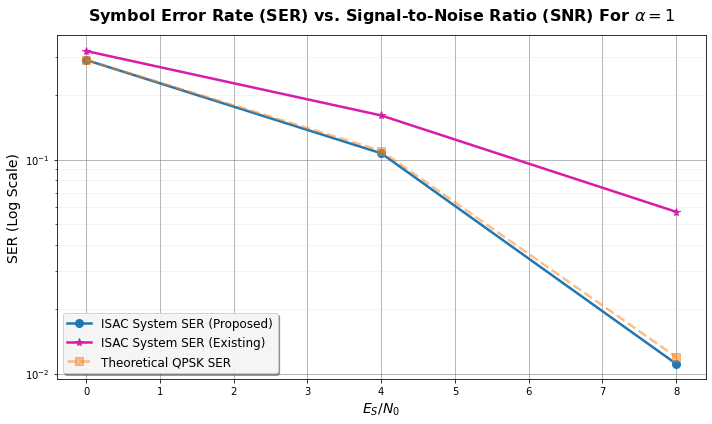

In [7]:
np.random.seed(42)

from scipy.special import erf

def Q(x):
    return 0.5-0.5*erf(x/np.sqrt(2))

SNR = [0, 4, 8]
StC_ratio = [1] # Sensing to Communication ratio
sigma = []


# M[h, w] = M[StC, SNR]
W, H = len(SNR), len(StC_ratio)

SER_ISAC = [[0 for x in range(W)] for y in range(H)] 
SER_OFDM = [[0 for x in range(W)] for y in range(H)]
SER_VOURAS = [[0 for x in range(W)] for y in range(H)]
SER_QAM = [[0 for x in range(W)] for y in range(H)]

iteration = 1e3

for i, r in enumerate(StC_ratio):

    alpha = r**2/(1+r**2)
    sensing_signal_isac = np.sqrt(alpha) * s_nulled
    sensing_signal_vouras = np.sqrt(alpha)* s_lin
    
    for v, SNR_val in enumerate(SNR):
        equal_num_isac = 0
        equal_num_ofdm = 0
        equal_num_vouras = 0
        SER_val_isac = SER_Comp(sensing_signal_isac, SNR_val , iteration, num_subcarriers,r=r, t=t , T=T)
        SER_val_vouras = SER_Comp(sensing_signal_vouras, SNR_val , iteration, num_subcarriers,r=r, t=t , T=T)

        SER_ISAC[i][v] = SER_val_isac
        SER_VOURAS[i][v] = SER_val_vouras
        print(f"Done with SNR={SNR_val} at alpha=")

        # חישוב עקומה תיאורטית
        SNR_lin = 10**(SNR_val / 10)
        SER_QAM[i][v] = 2*Q(np.sqrt(SNR_lin)) - (Q(np.sqrt(SNR_lin))**2)
    




for k in range(H):
    # Semi-log scale (y-axis in log scale)
    plt.figure(figsize=(10, 6))
    
    # ISAC
    plt.semilogy(SNR, SER_ISAC[k], 
                 marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=8, 
                 label='ISAC System SER (Proposed)')

    # Vouras    
    plt.semilogy(SNR, SER_VOURAS[k], 
                 marker='*', linestyle='-', color="#d91baa", linewidth=2.5, markersize=8, 
                 label='ISAC System SER (Existing)')
    
    # Theory (QPSK)
    plt.semilogy(SNR, SER_QAM[k], 
                 marker='s', linestyle='--', color='#ff7f0e', linewidth=2.5, markersize=8, alpha=0.5,
                 label='Theoretical QPSK SER')
    
    plt.title(r'Symbol Error Rate (SER) vs. Signal-to-Noise Ratio (SNR) For $\alpha=1$', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(r'$E_S$/$N_0$', fontsize=14)
    plt.ylabel('SER (Log Scale)', fontsize=14)
    plt.grid(True, which='major', linestyle='-', linewidth=0.8, color='gray', alpha=0.7)
    plt.grid(True, which='minor', linestyle='--', linewidth=0.5, color='lightgray', alpha=0.7)
    plt.legend(fontsize=12, loc='lower left', framealpha=0.9, shadow=True)
    plt.tight_layout()

plt.show()

In [12]:
np.random.seed(42)
r=1
alpha = r**2/(1+r**2)
sensing_signal_isac = np.sqrt(alpha) * s_nulled
sensing_signal_vouras = np.sqrt(alpha)* s_lin

SER_val_isac, isac_signal = SER_Comp(sensing_signal_isac, 8 , iteration, num_subcarriers,r=1, t=t , T=T, return_isac=True)
SER_val_vouras, vouras_signal = SER_Comp(sensing_signal_vouras, 8 , iteration,num_subcarriers,r=1, t=t , T=T, return_isac=True)

filename = 'simulation_results.npz'
with np.load(filename) as existing_data:
    data_dict = dict(existing_data)

data_dict['isac_siganl'] = isac_signal 
data_dict['vouras_siganl'] = vouras_signal 
# 3. שמירה מחדש של כל הנתונים (הישנים + החדש) לאותו קובץ
# הוספת ** לפני המילון מפרקת אותו לארגומנטים ש- np.savez יודע לקרוא
np.savez(filename, **data_dict)

print("The new variable 'signals' was successfully added to the file.")


iteration:  0
In SNR (8)
 ISAC 15816 from : 16000
iteration:  0
In SNR (8)
 ISAC 15073 from : 16000
The new variable 'signals' was successfully added to the file.


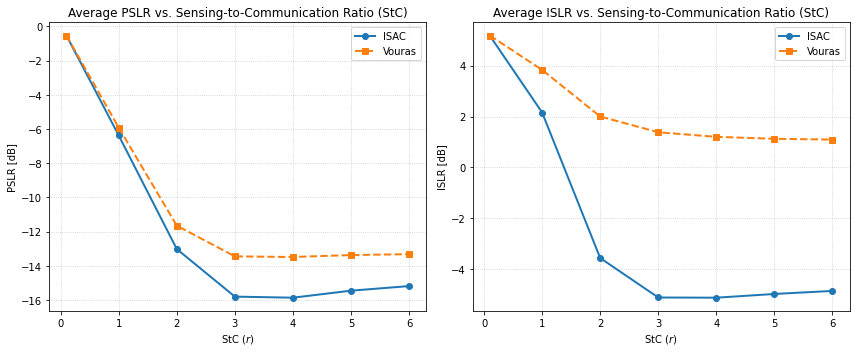

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Import the function (assuming it exists in the PSLR_ISLR_ISAC.py module)
from PSLR_ISLR_ISAC import calculate_mf_pslr_islr_numpy

np.random.seed(42)

StC = [0.1, 1, 2, 3, 4, 5, 6]
iterations = int(1e4) # Converted to integer for the loop range

# Properly initialize arrays using NumPy to avoid list append overhead/errors
vouras_PSLR = np.zeros(len(StC))
vouras_ISLR = np.zeros(len(StC))

isac_PSLR = np.zeros(len(StC))
isac_ISLR = np.zeros(len(StC))

for r_idx, r in enumerate(StC):
    alpha = r**2 / (1 + r**2)

    isac_pslr_tot = 0
    isac_islr_tot = 0

    vouras_pslr_tot = 0
    vouras_islr_tot = 0

    for i in range(iterations):

        # --- Data Generation ---
        data = np.random.randint(0, 2, num_subcarriers*2)
        QPSK_data = QPSK_modulation(data)
        OFDM_signal = OFDM(QPSK_data, t=t, num=num_subcarriers, normalize=True)

        # --- Signal Combination ---
        # Combine the radar signal (s_nulled / s_lin) with the communication signal (OFDM)
        tx_isac = np.sqrt(alpha) * s_nulled + np.sqrt(1 - alpha) * OFDM_signal
        tx_vouras = np.sqrt(alpha) * s_lin + np.sqrt(1 - alpha) * OFDM_signal

        # --- Linear Calculation ---
        # Calculate PSLR and ISLR in the linear power scale (db=False)
        isac_mf, isac_pslr, isac_islr = calculate_mf_pslr_islr_numpy(tx_isac, B=B, Fs=Fs, db=False)
        vouras_mf, vouras_pslr, vouras_islr = calculate_mf_pslr_islr_numpy(tx_vouras, B=B, Fs=Fs, db=False)

        # Accumulate the linear results for Vouras
        vouras_pslr_tot += vouras_pslr
        vouras_islr_tot += vouras_islr

        # Accumulate the linear results for ISAC
        isac_pslr_tot += isac_pslr
        isac_islr_tot += isac_islr
    
    # Calculate the linear average over all iterations for the current StC ratio
    vouras_PSLR[r_idx] = vouras_pslr_tot / iterations
    vouras_ISLR[r_idx] = vouras_islr_tot / iterations
    
    isac_PSLR[r_idx] = isac_pslr_tot / iterations
    isac_ISLR[r_idx] = isac_islr_tot / iterations

# ==========================================
# Conversion to Decibels (dB)
# ==========================================
# Since PSLR and ISLR represent power ratios, we use 10 * log10
vouras_PSLR_dB = 10 * np.log10(vouras_PSLR)
vouras_ISLR_dB = 10 * np.log10(vouras_ISLR)

isac_PSLR_dB = 10 * np.log10(isac_PSLR)
isac_ISLR_dB = 10 * np.log10(isac_ISLR)

# ==========================================
# Plotting the Results
# ==========================================
plt.figure(figsize=(12, 5))

# --- Plot 1: PSLR ---
plt.subplot(1, 2, 1)
plt.plot(StC, isac_PSLR_dB, marker='o', linewidth=2, label='ISAC')
plt.plot(StC, vouras_PSLR_dB, marker='s', linewidth=2, linestyle='--', label='Vouras')
plt.title('Average PSLR vs. Sensing-to-Communication Ratio (StC)')
plt.xlabel('StC ($r$)')
plt.ylabel('PSLR [dB]')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# --- Plot 2: ISLR ---
plt.subplot(1, 2, 2)
plt.plot(StC, isac_ISLR_dB, marker='o', linewidth=2, label='ISAC')
plt.plot(StC, vouras_ISLR_dB, marker='s', linewidth=2, linestyle='--', label='Vouras')
plt.title('Average ISLR vs. Sensing-to-Communication Ratio (StC)')
plt.xlabel('StC ($r$)')
plt.ylabel('ISLR [dB]')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#TODO add the limit - the original chirp!